In [2]:
import os
from obspy.taup.taup_create import build_taup_model

# 1. 设置你的 nd 文件名（请确保该文件已存在于当前目录下）
input_nd_file = "Model_1.nd" 
output_model_name = "Model_1" # 编译后的前缀

def compile_nd_to_npz(nd_file, model_name):
    # 检查输入文件是否存在
    if not os.path.exists(nd_file):
        print(f"❌ 错误：找不到输入文件 '{nd_file}'，请确认文件名正确。")
        return

    # 预先清理可能存在的旧版本，防止权限冲突或加载旧数据
    target_npz = f"{model_name}.npz"
    if os.path.exists(target_npz):
        os.remove(target_npz)
        print(f"清理旧模型: {target_npz}")

    try:
        print(f"正在转换 {nd_file} ...")
        # output_folder="." 强制输出到当前脚本运行的目录
        build_taup_model(nd_file, output_folder=".", verbose=True)
        
        # 验证是否成功生成
        if os.path.exists(target_npz):
            print(f"✅ 编译成功！生成的二进制模型位于: {os.path.abspath(target_npz)}")
        else:
            print("⚠️ 编译似乎结束了，但在当前目录没找到 .npz 文件。")
            
    except Exception as e:
        print(f"❌ 编译失败，报错信息如下：\n{e}")
        if "Moho depth is not specified" in str(e):
            print("\n💡 提示：请检查你的 .nd 文件，确保在地壳底部深度的下方，有一行单独写着 'mantle' 关键字。")
# 执行编译
compile_nd_to_npz(input_nd_file, output_model_name)

正在转换 Model_1.nd ...
Building obspy.taup model for 'Model_1.nd' ...


KeyboardInterrupt: 

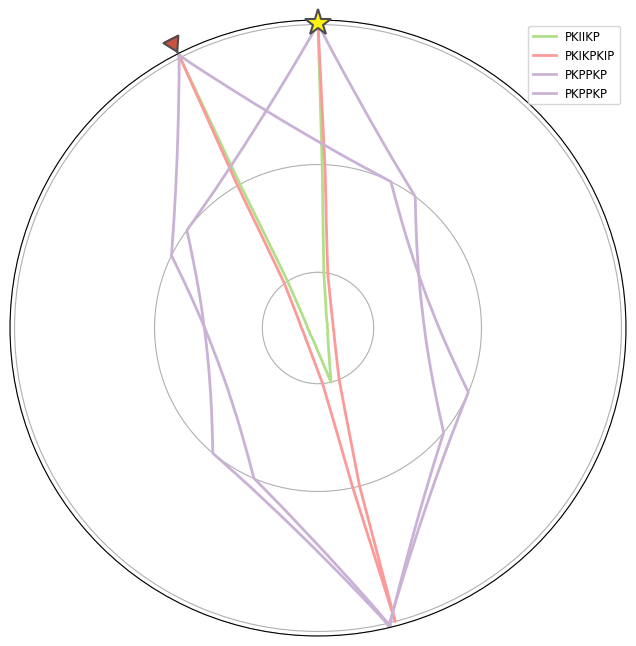

In [4]:
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
import os

model = TauPyModel(model="./mars.npz")

source_depth = 33
distance = 333
arrivals = model.get_ray_paths(
    source_depth_in_km=source_depth,
    distance_in_degree=distance,
    phase_list = ["PKIKPKIP","PKKP","PKPPKP","PKIIKP"]
)

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
if arrivals:
    arrivals.plot_rays(ax=ax, legend=True, plot_type='spherical')
    ax.set_title(f"PPP Path in Custom ND Model\nDepth: {source_depth}km, Dist: {distance}°")
else:
    print("未发现震相，请检查模型速度梯度或距离设置。")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from obspy.taup import TauPyModel
import os

model = TauPyModel(model="./mars_nocore.npz")

source_depth = 33
distance = 27
arrivals = model.get_ray_paths(
    source_depth_in_km=source_depth,
    distance_in_degree=distance,
    phase_list = ["PKPPKP","PKKP","PKIKPKIKP","PKIIKP"]
)

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
if arrivals:
    arrivals.plot_rays(ax=ax, legend=True, plot_type='spherical')
    ax.set_title(f"PPP Path in Custom ND Model\nDepth: {source_depth}km, Dist: {distance}°")
else:
    print("未发现震相，请检查模型速度梯度或距离设置。")

plt.show()